In [6]:
import math
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(42)

In [7]:
tickers = [
    "AAPL", "AMZN", "META", "MSFT", "GOOG", "NVDA",
    "TSLA", "ORCL", "WMT", "JPM", "LLY", "NFLX",
    "MA", "XOM", "JNJ", "PLTR", "COST", "HD", "BAC",
    "AMD", "PG", "UNH", "GE", "CVX", "KO", "CSCO",
    "TMUS", "IBM", "AXP", "CRM", "MCD", "MU", "PEP"
]
ticker_data_frames = []

stats = {}
def get_data(tick):
    ticker = yf.Ticker(tick)
    data = ticker.history(period="730d", interval="1h")

    ticker_df = pd.DataFrame({
        tick+"_open": data["Open"],
        tick+"_high": data["High"],
        tick+"_low": data["Low"],
        tick+"_close": data["Close"],
    })

    # THIS IS BAD !!!
    # MEAN = ticker_df.mean()
    # STD = ticker_df.std()
    # ticker_df = (ticker_df - MEAN) / STD

    ticker_data_frames.append(ticker_df)

for label in tickers:
    get_data(label)

print(f"Number of dataframes: {len(ticker_data_frames)}")
print(f"Number of columns: {len(ticker_data_frames[0].columns)}")
print(f"Number of rows: {len(ticker_data_frames[0])}")
ticker_data_frames[0].tail()

Number of dataframes: 33
Number of columns: 4
Number of rows: 5086


,AAPL_open,AAPL_high,AAPL_low,AAPL_close
Datetime,,,,
2025-10-24 11:30:00-04:00,263.290009,264.029999,262.950012,263.579987
2025-10-24 12:30:00-04:00,263.589996,263.709991,262.850006,263.609985
2025-10-24 13:30:00-04:00,263.609985,264.130005,263.410004,264.019989
2025-10-24 14:30:00-04:00,264.024994,264.100006,263.149994,263.500000
2025-10-24 15:30:00-04:00,263.510010,263.660004,262.130005,262.739990


In [8]:
# Combine all ticker frames
df = pd.concat(ticker_data_frames, axis=1)

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows with NaN
df.dropna(inplace=True)

print(f"Number of rows: {len(df)}")
df.head()

Number of rows: 5079


,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AMZN_open,AMZN_high,AMZN_low,AMZN_close,META_open,META_high,...,MCD_low,MCD_close,MU_open,MU_high,MU_low,MU_close,PEP_open,PEP_high,PEP_low,PEP_close
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-11-28 09:30:00-05:00,145.250000,146.639999,144.829895,145.130005,94.010002,96.400002,94.000000,94.172699,110.779999,112.040001,...,274.519989,274.970001,57.320000,57.759998,56.720001,56.840000,184.839996,185.492493,184.440002,184.764999
2022-11-28 10:30:00-05:00,145.130005,145.570007,144.770004,145.100006,94.169998,94.859901,93.809998,94.449997,109.430000,109.716599,...,273.829987,274.140015,56.840000,56.919998,56.360001,56.380001,184.779999,184.979996,184.440002,184.875000
2022-11-28 11:30:00-05:00,145.093994,145.755600,144.740005,145.179993,94.449997,95.250000,94.309998,94.470001,109.264999,109.449997,...,273.459991,274.220001,56.380001,56.500000,56.070000,56.349998,184.880005,185.300003,184.600006,185.259995
2022-11-28 12:30:00-05:00,145.175003,145.429901,144.699997,144.917007,94.470001,94.980003,94.180000,94.404999,109.267403,109.570000,...,273.750000,273.777496,56.355000,56.448601,56.169998,56.299999,185.250000,185.320007,184.589996,184.600006
2022-11-28 13:30:00-05:00,144.910004,144.949997,143.380005,143.539993,94.408096,94.449997,93.680000,94.002800,109.250000,109.410004,...,273.000000,273.010010,56.290001,56.314999,55.810001,55.820000,184.600006,184.699997,183.800003,183.869995


In [9]:
# 1 day = 6.5 hours
SEQUENCE_LENGTH = 13

def relative_change(sequences):
    result = sequences.copy()

    for i in range(sequences.shape[0]):
        for j in range(1, sequences.shape[1]):
            result[i, j, :] = (sequences[i, j, :] - sequences[i, j-1, :]) / sequences[i, j-1, :]

    return result[:, 1:, :]

In [10]:
# Create labels set
# labels = df.shift(-1)
# labels = labels.iloc[:-1]
# df = df.iloc[:-1]

# Sequence the full dataframe
sequences, sequence_labels = [], []
for i in range(len(df) - (SEQUENCE_LENGTH * 2)):
    sequences.append(df.iloc[i : i + SEQUENCE_LENGTH + 1].values)
    sequence_labels.append(df.iloc[i + SEQUENCE_LENGTH : i + (SEQUENCE_LENGTH * 2) + 1].values)
sequences = np.array(sequences)
sequence_labels = np.array(sequence_labels)

# Initial Shuffle
indices = np.random.permutation(len(sequences))
sequences = sequences[indices]
sequence_labels = sequence_labels[indices]

# Split
train_index = int(len(sequences) * 0.8)
train_sequences = sequences[:train_index]
train_labels = sequence_labels[:train_index]

other_sequences = sequences[train_index:]
other_labels = sequence_labels[train_index:]

# Shuffle remaining data
other_indices = np.random.permutation(len(other_sequences))
other_sequences = other_sequences[other_indices]
other_labels = other_labels[other_indices]

# Split again
index = int(len(other_sequences) * 0.5)
validation_sequences = other_sequences[:index]
validation_labels = other_labels[:index]

test_sequences = other_sequences[index:]
test_labels = other_labels[index:]

In [11]:
# Relative Change
train_sequences = relative_change(train_sequences)
train_labels = relative_change(train_labels)

validation_sequences = relative_change(validation_sequences)
validation_labels = relative_change(validation_labels)

test_sequences = relative_change(test_sequences)
test_labels = relative_change(test_labels)

In [12]:
# Normalize
training_mean = train_sequences.mean()
training_std = train_sequences.std()

train_sequences = (train_sequences - training_mean) / training_std
train_labels = (train_labels - training_mean) / training_std

validation_sequences = (validation_sequences - training_mean) / training_std
validation_labels = (validation_labels - training_mean) / training_std

test_sequences = (test_sequences - training_mean) / training_std
test_labels = (test_labels - training_mean) / training_std

# Transformer

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Ensure that the model dimension (d_model) is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Initialize dimensions
        self.d_model = d_model # Model's dimension
        self.num_heads = num_heads # Number of attention heads
        self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs
        self.W_q = nn.Linear(d_model, d_model) # Query transformation
        self.W_k = nn.Linear(d_model, d_model) # Key transformation
        self.W_v = nn.Linear(d_model, d_model) # Value transformation
        self.W_o = nn.Linear(d_model, d_model) # Output transformation

    """
    TODO
    We can swap this out for a potentially more
    effective embedding method.
    """
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)

        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [14]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [15]:
"""
TODO
Experiment with different positional encodings.
    - Topological feature based encodings? Can represent related
      time series data better (i.e. related stocks/companies).
"""
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [16]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)  # Prevents overfitting

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [17]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [18]:
class Transformer(nn.Module):
    def __init__(self, input_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        # Use Linear layers instead of Embedding for continuous numerical input
        self.encoder_input_layer = nn.Linear(input_size, d_model)
        self.decoder_input_layer = nn.Linear(input_size, d_model)

        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        # The output layer should predict the next sequence of continuous values,
        # so it should have an output size equal to the input size.
        self.fc = nn.Linear(d_model, input_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt):
        # Apply linear transformation and positional encoding
        src_embedded = self.dropout(self.positional_encoding(self.encoder_input_layer(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_input_layer(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            # Pass None for the mask as it's not used
            enc_output = enc_layer(enc_output, None)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            # Pass None for masks as they are not used
            dec_output = dec_layer(dec_output, enc_output, None, None)

        output = self.fc(dec_output)
        return output

# Setup & Training

In [19]:
# Convert numpy arrays to PyTorch tensors
# The data is continuous, so use float tensors instead of long tensors
src_data = torch.tensor(train_sequences).float().to(device)
tgt_data = torch.tensor(train_labels).float().to(device)

# The input size to the Transformer should be the number of features (columns)
input_size = train_sequences.shape[-1]

# Parameters
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = SEQUENCE_LENGTH
dropout = 0.1
epoch_num = 50

# Initialize the Transformer with the correct input size
transformer = Transformer(input_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout).to(device)

In [20]:
# Use Mean Squared Error Loss for continuous output
criterion = nn.MSELoss()

# Optimizer for dyanmic adjustment of learning rate
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

train_loader = DataLoader(TensorDataset(src_data, tgt_data), batch_size=64, shuffle=True)

transformer.train()
for epoch in range(50):
    for x, y in train_loader:
        optimizer.zero_grad()

        x = x.to(device).float()
        y = y.to(device).float()

        output = transformer(x, y[:, :-1, :])
        loss = criterion(output, y[:, 1:, :])

        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 0.5878050923347473
Epoch: 2, Loss: 0.5167727470397949
Epoch: 3, Loss: 0.5516510605812073
Epoch: 4, Loss: 0.21228811144828796
Epoch: 5, Loss: 0.2711182236671448
Epoch: 6, Loss: 0.19263897836208344
Epoch: 7, Loss: 0.3043063282966614
Epoch: 8, Loss: 0.11055120080709457
Epoch: 9, Loss: 0.27927127480506897
Epoch: 10, Loss: 0.25428450107574463
Epoch: 11, Loss: 0.15010647475719452
Epoch: 12, Loss: 0.13422173261642456
Epoch: 13, Loss: 0.1381896734237671
Epoch: 14, Loss: 0.2801814079284668
Epoch: 15, Loss: 0.21820302307605743
Epoch: 16, Loss: 0.15740306675434113
Epoch: 17, Loss: 0.11863436549901962
Epoch: 18, Loss: 0.138521209359169
Epoch: 19, Loss: 0.14480556547641754
Epoch: 20, Loss: 0.1579740047454834
Epoch: 21, Loss: 0.10806117951869965
Epoch: 22, Loss: 0.0711652860045433
Epoch: 23, Loss: 0.10829512029886246
Epoch: 24, Loss: 0.0904022753238678
Epoch: 25, Loss: 0.08422588557004929
Epoch: 26, Loss: 0.10080964863300323
Epoch: 27, Loss: 0.06095505878329277
Epoch: 28, Loss: 0.078

In [21]:
val_loader = DataLoader(TensorDataset(torch.tensor(validation_sequences).float().to(device), torch.tensor(validation_labels).float().to(device)), batch_size=64, shuffle=False)

transformer.eval()

with torch.no_grad():
    val_loss = 0.0
    for x, y in val_loader: # Iterate over the validation data loader
        x = x.to(device).float()
        y = y.to(device).float()

        # Adjust slicing for validation target data
        val_output = transformer(x, y[:, :-1, :])

        # Adjust the target for loss calculation
        val_loss += criterion(val_output, y[:, 1:, :]).item()

    # Calculate average validation loss
    val_loss /= len(val_loader)
    print(f"Validation Loss: {val_loss}")

Validation Loss: 0.08253651671111584


In [22]:
def autoregressive_prediction(model, input_data, sequence_length):
    model.eval()

    predictions = []
    with torch.no_grad():
        # Initialize the decoder input with the last element of the source sequence
        decoder_input = input_data[:, -1:, :].to(device)

        for _ in range(sequence_length):
            # Use the transformer to predict the next step based on the decoder_input
            prediction = model(input_data, decoder_input)

            # Get the last entry of the prediction
            next_step_prediction = prediction[:, -1:, :]

            # Add it to the list
            predictions.append(next_step_prediction.cpu().numpy())

            decoder_input = torch.cat((decoder_input, next_step_prediction), dim=1)

    return np.concatenate(predictions, axis=1)

def non_autoregressive_prediction(model, input_data):
    model.eval()

    with torch.no_grad():
        prediction = model(input_data, input_data)

    return prediction.cpu().numpy()

def MSE(pred, actual):
    return np.mean((actual - pred) ** 2)

def MAE(pred, actual):
    return np.mean(np.abs(actual - pred))

In [ ]:
transformer.eval()

test_src_data = torch.tensor(test_sequences).float().to(device)

# predicted_auto = autoregressive_prediction(transformer, test_src_data.clone(), SEQUENCE_LENGTH)[:, 1:, :]
predicted_nonauto = non_autoregressive_prediction(transformer, test_src_data.clone())
actual_plot_data = test_labels.copy()

Mean MSE: 1.2283747567389345
Median MSE: 0.6873419822340874


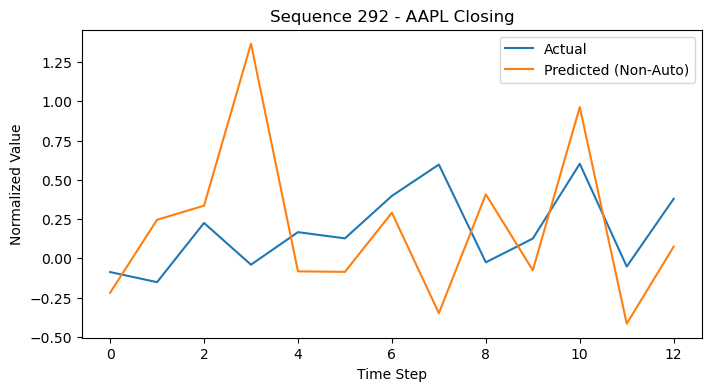

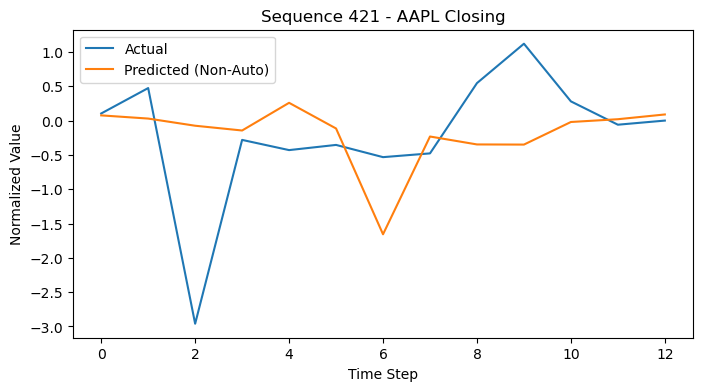

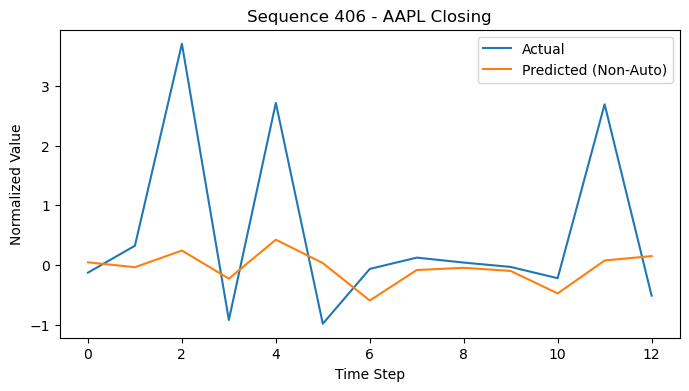

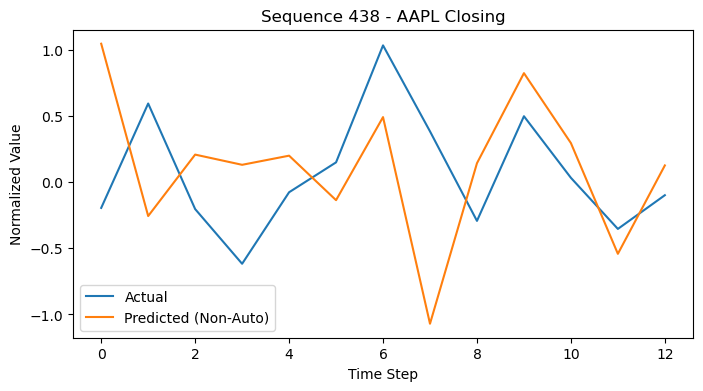

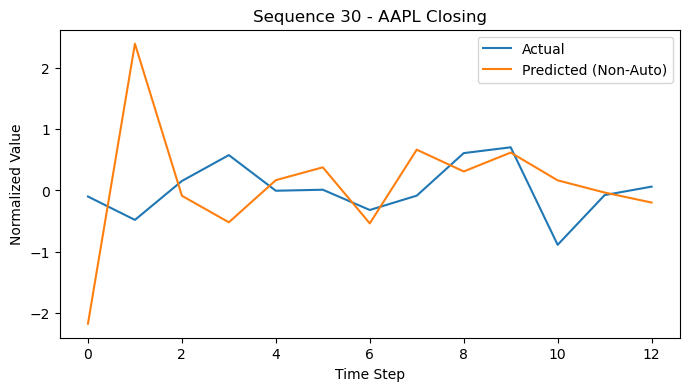

In [27]:
# Calculate Mean and Median MSE over all sequences
stats = []
for x in range(actual_plot_data.shape[0]):
    stats.append(MSE(predicted_nonauto[x, :, 3], actual_plot_data[x, :, 3]))
mean_mse = np.mean(stats)
median_mse = np.median(stats)

print(f"Mean MSE: {mean_mse}")
print(f"Median MSE: {median_mse}")

# Plot a few sequences to visualize the predictions
num_plots = 5
for i in range(num_plots):
    plt.figure(figsize=(8, 4))

    p = int(np.random.rand() * actual_plot_data.shape[0])
    x_values = np.arange(SEQUENCE_LENGTH)

    plt.plot(x_values, actual_plot_data[p, :, 3], label='Actual')
    # plt.plot(x_values, predicted_auto[i, :, 3], label='Predicted (Auto)')
    plt.plot(x_values, predicted_nonauto[p, :, 3], label='Predicted (Non-Auto)')
    plt.title(f'Sequence {p} - AAPL Closing')
    plt.xlabel('Time Step')
    plt.ylabel('Normalized Value')
    plt.legend()
    plt.show()

/tmp/ipykernel_54579/1554498102.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start=start_date, end=end_date, interval='1h')
[*********************100%***********************]  1 of 1 completed


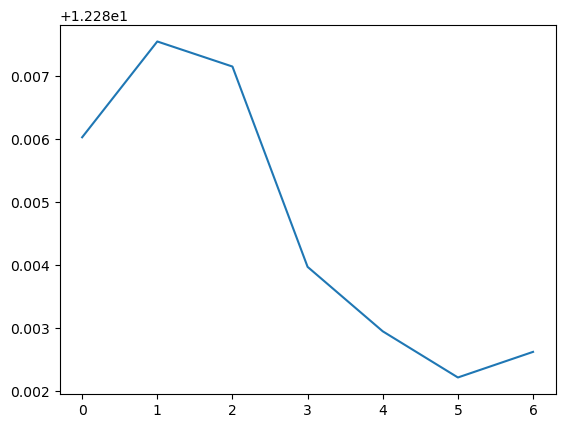

In [25]:
from datetime import datetime, timedelta

end_date = datetime.now().date()
start_date = end_date - timedelta(hours=26)

data = yf.download("AAPL", start=start_date, end=end_date, interval='1h')
data.drop(columns=['Volume'], inplace=True)

data = torch.tensor(data.values).float().to(device).unsqueeze(0)
data = torch.nn.functional.pad(data, (0, 128), mode='constant', value=0)

pred = non_autoregressive_prediction(transformer, data)

x_values = np.arange(7)

plt.plot(x_values, pred[0, :, 3], label='Actual')
plt.show()